In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('amazon_eco-friendly_products.csv')

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (3587, 14)


,id,title,name,category,material,brand,price,rating,reviewsCount,description,url,img_url,inStock,inStockText
0,B0CWH366KJ,"Agfabric Natural Jute Erosion Control, 16yard(...",Weed Barrier Fabric,"Patio, Lawn & Garden",NaN,Agfabric,$87.3,NaN,NaN,Protect your yard and garden with our biodegra...,https://www.amazon.com/dp/B0CWH366KJ,https://m.media-amazon.com/images/I/71t3FD5KjH...,True,Only 5 left in stock - order soon.
1,B086L692VC,SAFAVIEH Braided Collection 4' Round Light Blu...,Area Rugs,Home & Kitchen,"50%jute, 25% Wool, 25% Cotton",Safavieh,$40.63,4.2,59.0,Country style is perfect for a casual cottage ...,https://www.amazon.com/dp/B086L692VC,https://m.media-amazon.com/images/I/A1Q73Cheh2...,True,Only 3 left in stock - order soon.
2,B01J6JELTG,Eyeseals 4.0 Sleep Mask – Clear – Moisturizing...,Sleeping Masks,Health & Household,Plastic,EYEECO,$65.95,3.7,1075.0,Locks moisture in: Eyeseals 4.0 eye mask for d...,https://www.amazon.com/dp/B01J6JELTG,https://m.media-amazon.com/images/I/61Uz393xlp...,True,NaN
3,B07HQSKK36,Lucky Monet 25/50/100PCS Burlap Gift Bags Wedd...,Gift Bags,Health & Household,Burlap,Lucky Monet,$29.99,4.6,2492.0,❤ Premium Burlap Material❤ These small burlap ...,https://www.amazon.com/dp/B07HQSKK36,https://m.media-amazon.com/images/I/71DrHIU1aM...,True,In Stock In Stock
4,B0C3Y8WJDR,St. Boniface Bag Company | Burlap Bags - Size:...,Grow Bags,"Patio, Lawn & Garden",5.0 Count,Generic,$29.99,4.4,11.0,100% Burlap > 100% BIODEGRADABLE AND ECO FRIEN...,https://www.amazon.com/dp/B0C3Y8WJDR,https://m.media-amazon.com/images/I/81q3el899U...,True,In Stock


In [2]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3587 entries, 0 to 3586
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            3587 non-null   object 
 1   title         3587 non-null   object 
 2   name          3558 non-null   object 
 3   category      3558 non-null   object 
 4   material      2878 non-null   object 
 5   brand         3414 non-null   object 
 6   price         3356 non-null   object 
 7   rating        3341 non-null   float64
 8   reviewsCount  3341 non-null   float64
 9   description   3139 non-null   object 
 10  url           3587 non-null   object 
 11  img_url       3587 non-null   object 
 12  inStock       2912 non-null   object 
 13  inStockText   3259 non-null   object 
dtypes: float64(2), object(12)
memory usage: 392.5+ KB


In [3]:
df.describe()

,rating,reviewsCount
count,3341.000000,3341.000000
mean,4.467555,3795.543550
std,0.333330,13350.874821
min,1.000000,1.000000
25%,4.300000,82.000000
50%,4.500000,455.000000
75%,4.700000,2402.000000
max,5.000000,267025.000000


In [4]:
# Missing Values Analysis
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percent
}).sort_values(by='Percentage', ascending=False)

print(missing_df)

              Missing Values  Percentage
material                 709   19.765821
inStock                  675   18.817954
description              448   12.489546
inStockText              328    9.144132
rating                   246    6.858099
reviewsCount             246    6.858099
price                    231    6.439922
brand                    173    4.822972
name                      29    0.808475
category                  29    0.808475
id                         0    0.000000
title                      0    0.000000
img_url                    0    0.000000
url                        0    0.000000


In [5]:
# Remove currency symbols and convert to numeric
df['price'] = df['price'].replace(r'[^\d.]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

df['price'].describe()

count    2725.000000
mean       24.956932
std        32.048009
min         1.400000
25%        10.500000
50%        16.990000
75%        25.990000
max       477.820000
Name: price, dtype: float64

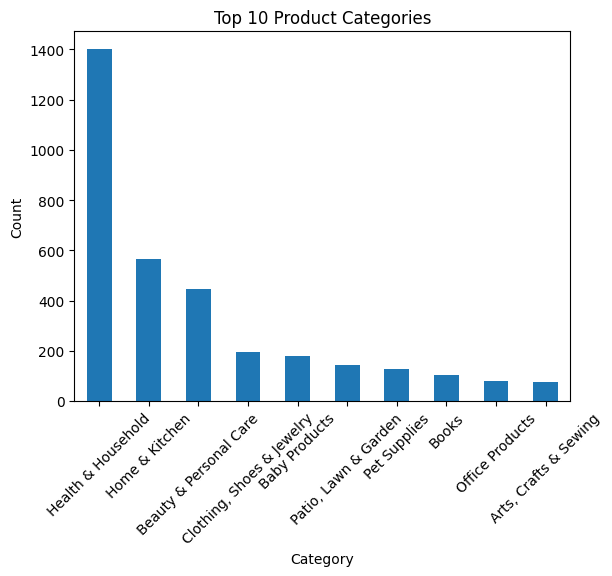

In [6]:
#Category Distribution
category_counts = df['category'].value_counts()

plt.figure()
category_counts.head(10).plot(kind='bar')
plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

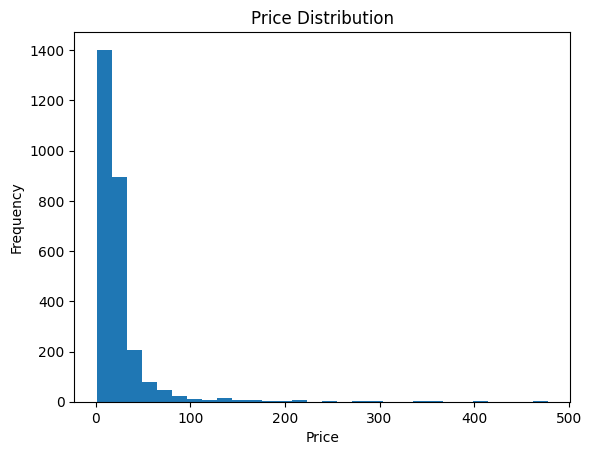

In [7]:
# Price Distribution

plt.figure()
df['price'].dropna().plot(kind='hist', bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

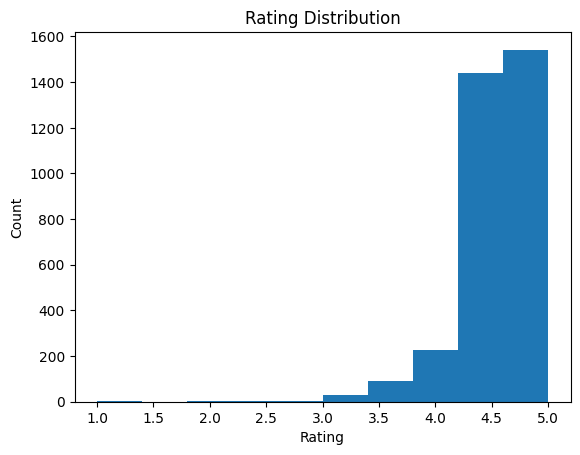

In [8]:
# Rating Distribution
plt.figure()
df['rating'].dropna().plot(kind='hist', bins=10)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

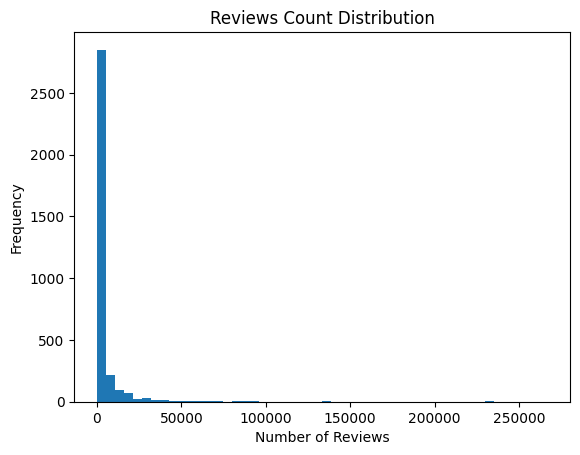

In [9]:
# Reviews Count (Long Tail)
plt.figure()
df['reviewsCount'].dropna().plot(kind='hist', bins=50)
plt.title("Reviews Count Distribution")
plt.xlabel("Number of Reviews")
plt.ylabel("Frequency")
plt.show()

In [10]:
#Correlation
numeric_df = df[['price', 'rating', 'reviewsCount']]

corr = numeric_df.corr()
print(corr)

                 price    rating  reviewsCount
price         1.000000 -0.039694     -0.048276
rating       -0.039694  1.000000      0.080468
reviewsCount -0.048276  0.080468      1.000000
